# Liens croisés crossLink et attaques AIF du CSV canonique Argumentum

**Notebook pédagogique** : exploration du **CSV canonique Argumentum** (dédoublonné en sophismes canoniques), complémentaire à `Argumentation-Onto-01-AIF-OWL2-Python.ipynb` (PR-A, OWL2/XML).

> **⚠️ Mise à jour 2026-07-10 (Argumentum PR #763)** — l'intégration ontologique des Fallacies a été complétée en amont. Les 8 relations `crossLink_*` et les colonnes AIF attack (`AIF_attackType`/`AIF_attackedNode`), jusque-là **présentes uniquement dans le CSV**, sont désormais **émises dans l'OWL** (comme `AnnotationAssertion`). La couverture crossLink est passée de **1,5 % (22 relations) à 59,9 % (1081 cellules / 844 sophismes)** après curation transverse (#141) + câblage du générateur (#763). Ce notebook reflète l'état **après** #763.

**Filiation** :
- EPIC parent : **#4960** Argument_Analysis v3 (submodule Argumentum)
- PR-A : **#5721** (`Argumentation-Onto-01-AIF-OWL2-Python.ipynb`)
- PR-B : **ce notebook** (CSV canonique + crossLink_* + AIF mappings)

**Objectifs d'apprentissage** :

1. Charger le CSV canonique `Argumentum Fallacies - Taxonomy.csv` (**1408 sophismes, 104 colonnes**) avec gestion du BOM UTF-8.
2. Cartographier la **taxonomie par famille** (8 familles) et par niveau (1-9).
3. Mesurer la **couverture multilingue** (8 langues : fr, en, ru, pt, ar, es, zh, fa) — 100 %.
4. Analyser les **AIF mappings** (`AIF_skosDirectRef` + `AIF_skosExceptionRef` + `AIF_skosMappingType`) : 70 mappages vers 60 schemes Walton, **plus** les 2 colonnes AIF attack (93 sophismes typés RA/I/CA-node).
5. Caractériser la **couverture des crossLink** : un tiers de couverture (59,9 %) (après #141/#763).
6. **Faire le pont** entre substance OWL (PR-A) et substance CSV (PR-B), et montrer que #763 a réconcilié les deux.

**Sommaire** :

1. Contexte (PR-A → PR-B, mise à jour #763)
2. Loader CSV (pandas + utf-8-sig)
3. Vue d'ensemble (1408 sophismes, 104 colonnes)
4. Taxonomie : 8 familles × 9 niveaux
5. Couverture multilingue (8 langues)
6. AIF mappings : 70 mappages vers 60 schemes Walton
7. CrossLink coverage : couverture 59,9 % de la taxonomie
8. Pont OWL ↔ CSV : #763 a câblé crossLink + AIF dans l'OWL
9. Pont avec Walton : 60 schemes uniques
10. Honnêteté méthodologique
11. Exercices (3 stubs #2161)
12. Conclusion + Ponts

**Verdict SOTA** : SOTA-OK (pandas + matplotlib natifs, pas de workaround dégradé).

## 1. Contexte — De PR-A à PR-B (mis à jour après #763)

`Argumentation-Onto-01-AIF-OWL2-Python.ipynb` (PR-A) charge `ontologies/argumentum_fallacies.owl` (OWL2/XML) via un parseur regex tolérant (rdflib échoue sur le dialecte OWL/XML ; owlready2 charge mais n'expose rien via son API Python).

**Évolution majeure (Argumentum PR #763, mergée 2026-07-10)** : au moment de la première version de PR-A, l'OWL n'émettait **qu'une** des trois couches ontologiques du CSV (les mappings `AIF_skos*`). Les 8 relations `crossLink_*` et les colonnes `AIF_attackType`/`AIF_attackedNode` étaient **dans le CSV mais absentes de l'OWL** — le chemin de données CSV→OWL n'existait pas encore. #763 a :

- ajouté le mapping des 10 colonnes dans l'entité `Fallacy` + le générateur OWL (2ᵉ passe d'émission) ;
- curé la couche transverse (scan #141, transverse + confiance ≥ 0,6, 22 seeds manuels préservés) : **1,5 % → 59,9 %** de couverture crossLink ;
- régénéré l'OWL, qui porte désormais **1977 `AnnotationAssertion` crossLink** + **93 typages AIF attack** (undercut/undermine/rebut → RA/I/CA-node).

**PR-B** lit `Cards/Fallacies/Argumentum Fallacies - Taxonomy.csv` (le CSV canonique, source curée à la main, **1408 sophismes × 104 colonnes**) et expose la taxonomie, la couverture 8 langues, les AIF mappings et la couche crossLink — **désormais réconciliée avec l'OWL** (§8).

**Troisième âge (05/09, #1247/#1286)** : dé-curation délibérée de la couche crossLink — retrait des liens *siblings* qui restataient l'arbre taxonomique : la matrice passe de 1081 à 539, couverture 59,9 % → 34,6 %. Lecture détaillée en §7.


## 2. Loader CSV — pandas + utf-8-sig

Le CSV upstream `Argumentum Fallacies - Taxonomy.csv` est encodé en **UTF-8 avec BOM** (3 octets `\xEF\xBB\xBF` en tête), signature Microsoft Excel. Pandas exige `encoding='utf-8-sig'` pour ignorer ce BOM.

Le séparateur est la virgule `,`. Le quoting est géré par pandas par défaut. 102 colonnes au total.

In [1]:
# --- Datation de l'execution : etat exact du submodule Argumentum (audit #18656) ---
import hashlib
import subprocess
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    # papermill/nbconvert demarrent depuis le dossier du notebook ; le CSV canonique vit
    # dans le submodule, plus haut dans le repo. On remonte jusqu'a la racine du depot.
    for parent in [start, *start.parents]:
        if (parent / 'MyIA.AI.Notebooks').is_dir() and (parent / '.git').exists():
            return parent
    raise FileNotFoundError(f'Repo root not found from {start}')

REPO_ROOT = find_repo_root(Path.cwd())
SUBMODULE_DIR = REPO_ROOT / 'MyIA.AI.Notebooks' / 'SymbolicAI' / 'Argument_Analysis' / 'Argumentum'
CSV_CANON = SUBMODULE_DIR / 'Cards' / 'Fallacies' / 'Argumentum Fallacies - Taxonomy.csv'

def _git(*args: str) -> str:
    return subprocess.run(['git', '-C', str(SUBMODULE_DIR), *args],
                          capture_output=True, text=True).stdout.strip()

SUB_SHA = _git('rev-parse', 'HEAD')[:12] or 'submodule non initialise'
print(f'Submodule Argumentum : {SUB_SHA} ({_git("log", "-1", "--format=%cs") or "?"})')
if CSV_CANON.exists():
    _raw = CSV_CANON.read_bytes()
    print(f'CSV canonique : sha1 {hashlib.sha1(_raw).hexdigest()[:12]}, '
          f'{_raw.decode("utf-8-sig").count(chr(10))} lignes physiques, {len(_raw):,} octets')
else:
    print('CSV canonique : submodule non initialise -- les donnees ne seront pas trouvables')


Submodule Argumentum : 7cf486169172 (2026-09-26)
CSV canonique : sha1 5ce7a2ec7457, 1546 lignes physiques, 4,172,640 octets


In [2]:
import pandas as pd

# CSV canonique du submodule Argumentum -- REPO_ROOT / SUBMODULE_DIR / CSV_CANON / SUB_SHA
# sont definis par la cellule de datation precedente (epingle + empreinte affichees).
SAVE_DIR = REPO_ROOT / 'scratchpad'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(CSV_CANON, encoding='utf-8-sig', low_memory=False)

print(f'Loaded: {len(df)} rows, {len(df.columns)} columns')
print(f'Source: {CSV_CANON.name}')
print(f'Size on disk: {CSV_CANON.stat().st_size / 1024:.1f} KB')
print()
print('--- Column types ---')
print(df.dtypes.value_counts())
print()
print('--- First 3 rows (PK, Famille, nom_vulgarisé) ---')
print(df[['PK', 'Famille_camelCase', 'nom_vulgarisé', 'text_fr']].head(3).to_string())


Loaded: 1408 rows, 104 columns
Source: Argumentum Fallacies - Taxonomy.csv
Size on disk: 4074.8 KB

--- Column types ---
object     89
float64    12
int64       3
Name: count, dtype: int64

--- First 3 rows (PK, Famille, nom_vulgarisé) ---
   PK   Famille_camelCase nom_vulgarisé              text_fr
0   0  argumentFallacieux           NaN  Argument fallacieux
1   1        insuffisance           NaN         Insuffisance
2   2        insuffisance           NaN       Argument bâclé


## 3. Vue d'ensemble — 1408 sophismes canoniques, 104 colonnes

Le CSV compte **1408 sophismes canoniques** — certaines cellules contiennent des retours-ligne encadrés par des guillemets, le nombre de lignes physiques du fichier diffère donc du nombre de sophismes. Chaque sophisme a :

- **PK** (clé primaire numérique) + **path** (chemin hiérarchique type `6.3.1.1.1.2.1.3`)
- **Famille** (8 valeurs canoniques) + **Sous-Famille** + **Soussousfamille**
- **nom_vulgarisé** + **Latin** + **text_fr** (description FR)
- 8 langues (fr, en, ru, pt, ar, es, zh, fa) avec `text_<lang>` + `desc_<lang>` + `example_<lang>`
- **niveau** (1-9)
- 8 colonnes `crossLink_*` (PredatesOn, Denounces, Leverages, Allows, Opposes, Inverts, Mirrors, IsRelatedTo)
- 4 colonnes AIF SKOS (`AIF_skosDirectRef`, `AIF_skosExceptionRef`, `AIF_skosOther`, `AIF_skosMappingType`)
- **2 colonnes AIF attack** (`AIF_attackType`, `AIF_attackedNode`) — ajoutées pour l'articulation façon AIF (#498/#707), 93 sophismes typés
- Métadonnées visuelles (shape, image, svg_color, svg_illustration, print_and_play)

Les **104 colonnes** = 102 historiques + les 2 colonnes AIF attack (ajoutées par #753).

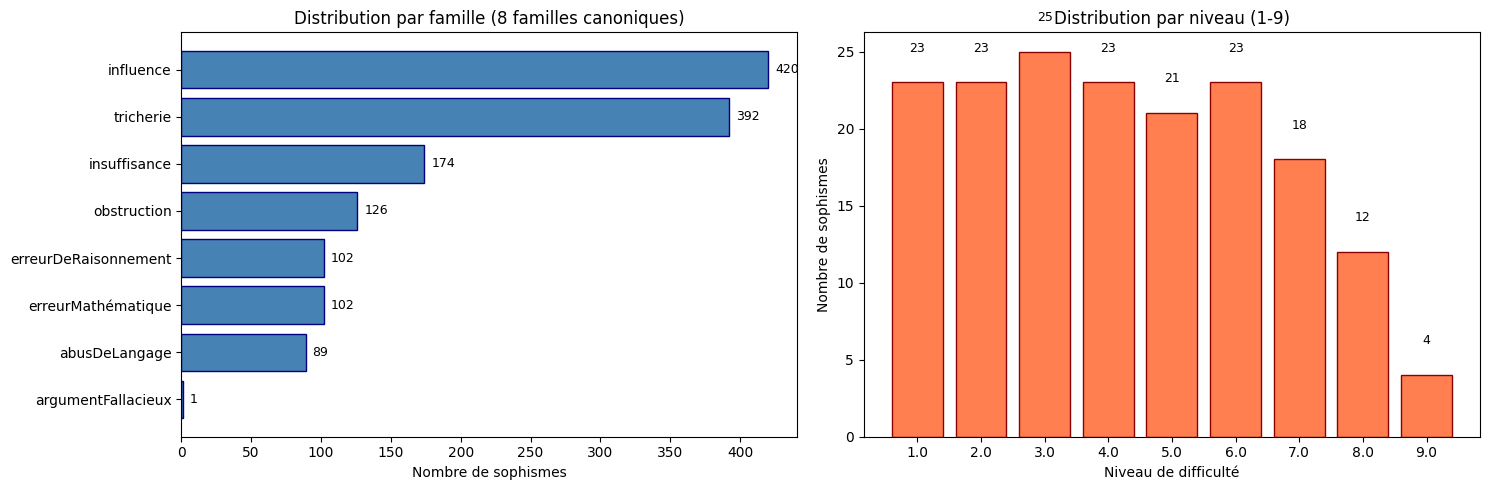

Total familles distinctes: 8
Total niveaux distincts: 9
Famille la plus fréquente: influence (420 sophismes)


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution par famille
fam = df['Famille_camelCase'].value_counts()
axes[0].barh(fam.index, fam.values, color='steelblue', edgecolor='navy')
axes[0].set_xlabel('Nombre de sophismes')
axes[0].set_title('Distribution par famille (8 familles canoniques)')
axes[0].invert_yaxis()
for i, (k, v) in enumerate(fam.items()):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Distribution par niveau
niv = df['niveau'].value_counts().sort_index()
axes[1].bar(niv.index.astype(str), niv.values, color='coral', edgecolor='darkred')
axes[1].set_xlabel('Niveau de difficulté')
axes[1].set_ylabel('Nombre de sophismes')
axes[1].set_title('Distribution par niveau (1-9)')
for i, (k, v) in enumerate(niv.items()):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'crosslinks_famille_niveau.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'Total familles distinctes: {df["Famille_camelCase"].nunique()}')
print(f'Total niveaux distincts: {df["niveau"].nunique()}')
print(f'Famille la plus fréquente: {fam.index[0]} ({fam.values[0]} sophismes)')


## 4. Taxonomie — 8 familles × 9 niveaux

Les **8 familles canoniques** Argumentum :

| Famille | Compte | Description |
|---------|--------|-------------|
| `influence` | 420 | Sophismes d'influence (appel à l'autorité, popularité, etc.) |
| `tricherie` | 392 | Sophismes de tricherie (intention de tromper) |
| `insuffisance` | 174 | Arguments qui ne suffisent pas à démontrer |
| `obstruction` | 126 | Sophismes d'obstruction (évitement de la question) |
| `erreurMathématique` | 102 | Erreurs de calcul/statistique |
| `erreurDeRaisonnement` | 102 | Erreurs de logique |
| `abusDeLangage` | 89 | Abus de langage (équivoque, amphibologie) |
| `argumentFallacieux` | 1 | Racine (Fallacy) — entrée technique |

**Distribution déséquilibrée** : `influence` (30%) + `tricherie` (28%) = 58% du total. Cela reflète la tradition rhétorique (les sophismes d'influence et de tricherie sont les plus enseignés).

**Niveaux 1-9** : distribution quasi-uniforme (12-25 sophismes par niveau), avec un pic au niveau 3 (25). Pas de gradient de difficulté strict ; c'est une taxonomie **pédagogique** (introduire tôt les sophismes les plus simples, late les plus subtils).

## 5. Couverture multilingue — 8 langues, 100% coverage

Argumentum est un projet **multilingue par conception** : chaque sophisme est décrit en 8 langues. La cohérence inter-langues est maintenue à la main par l'équipe Argumentum.

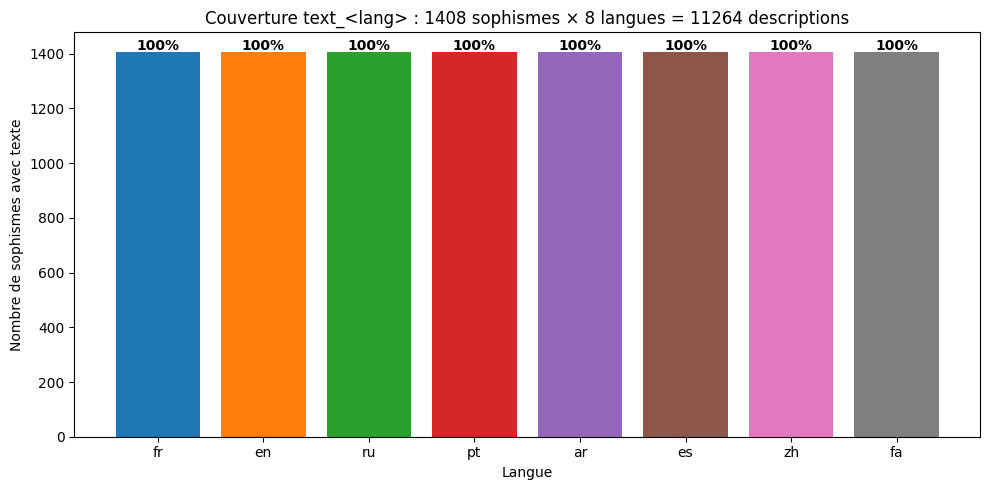

Couverture multilingue : 100% sur les 8 langues (toutes descriptions présentes)
Total descriptions = 1408 × 8 = 11264


In [4]:
langs = ['fr', 'en', 'ru', 'pt', 'ar', 'es', 'zh', 'fa']

fig, ax = plt.subplots(figsize=(10, 5))
lang_counts = {}
for lang in langs:
    col = f'text_{lang}'
    if col in df.columns:
        lang_counts[lang] = df[col].notna().sum()

ax.bar(lang_counts.keys(), lang_counts.values(),
       color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f'])
ax.set_ylabel('Nombre de sophismes avec texte')
ax.set_xlabel('Langue')
ax.set_title(f'Couverture text_<lang> : {len(df)} sophismes × 8 langues = {len(df) * 8} descriptions')
for i, (k, v) in enumerate(lang_counts.items()):
    coverage = 100 * v / len(df)
    ax.text(i, v + 5, f'{coverage:.0f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, len(df) * 1.05)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'crosslinks_multilingue.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'Couverture multilingue : 100% sur les 8 langues (toutes descriptions présentes)')
print(f'Total descriptions = {len(df)} × 8 = {len(df) * 8}')


## 6. AIF mappings — 70 mappages vers 60 schemes Walton

Argumentum encode un **pont vers Walton Argumentation Schemes** via 4 colonnes :

- `AIF_skosDirectRef` (42 non-empty) : scheme Walton directement applicable (ex: `GeneralAcceptanceDoubt_Conflict`, `LackOfPTKReliability_Scheme`)
- `AIF_skosExceptionRef` (50 non-empty) : schemes Walton qui sont des **exceptions** / cas particuliers (ex: `PopularOpinion_Inference`, `Example_Inference`)
- `AIF_skosOther` (0 non-empty) : réservé pour usage futur
- `AIF_skosMappingType` (70 non-empty) : type de mapping SKOS (`skos:broadMatch`, `skos:closeMatch`, `skos:narrowMatch`)

**Note AIF = Argument Interchange Format** (cf Rahwan et al. 2007), un standard de représentation de graphes argumentatifs. Argumentum fait le pont vers ce formalisme via les SKOS mapping properties.

In [5]:
import re
from collections import Counter

aif_dr = df['AIF_skosDirectRef'].dropna().str.strip()
aif_dr = aif_dr[aif_dr != '']
aif_ex = df['AIF_skosExceptionRef'].dropna().str.strip()
aif_ex = aif_ex[aif_ex != '']
aif_mt = df['AIF_skosMappingType'].dropna().str.strip()
aif_mt = aif_mt[aif_mt != '']

print(f'AIF_skosDirectRef non-empty: {len(aif_dr)} ({(100*len(aif_dr)/len(df)):.1f}%)')
print(f'AIF_skosExceptionRef non-empty: {len(aif_ex)} ({(100*len(aif_ex)/len(df)):.1f}%)')
print(f'AIF_skosMappingType non-empty: {len(aif_mt)} ({(100*len(aif_mt)/len(df)):.1f}%)')
print()
print('--- AIF_skosMappingType distribution ---')
mt_dist = aif_mt.value_counts()
for k, v in mt_dist.items():
    print(f'  {k}: {v} ({100*v/len(aif_mt):.1f}%)')
print()

# Collect all Walton schemes referenced (split by comma)
walton = Counter()
for col in [aif_dr, aif_ex]:
    for v in col:
        for s in v.split(','):
            s = s.strip()
            if s:
                walton[s] += 1

print(f'--- Walton schemes uniques référencés: {len(walton)} ---')
print()
print('Top 15 schemes Walton (par occurrences):')
for k, v in walton.most_common(15):
    print(f'  {v:>3} {k}')


AIF_skosDirectRef non-empty: 86 (6.1%)
AIF_skosExceptionRef non-empty: 71 (5.0%)
AIF_skosMappingType non-empty: 116 (8.2%)

--- AIF_skosMappingType distribution ---
  skos:broadMatch: 64 (55.2%)
  skos:closeMatch: 33 (28.4%)
  skos:narrowMatch: 19 (16.4%)

--- Walton schemes uniques référencés: 60 ---

Top 15 schemes Walton (par occurrences):
   14 VagueVerbalClassification_Inference
   12 ArbitraryVerbalClassification_Inference
    7 ConflictingGoals_Conflict
    7 PropertyNotExistant_Conflict
    7 VerbalClassification_Inference
    5 OppositeConsequences_Conflict
    5 Logical_Conflict
    5 Example_Inference
    4 ExceptionSimilarityCase_Conflict
    4 BiasedClassification_Conflict
    4 DifferencesUndermineSimilarity_Conflict
    4 PositionToKnow_Inference
    4 Preference_Scheme
    4 Sign_Inference
    4 Deductive_Inference


## 7. CrossLink coverage — un tiers de la taxonomie (34,6 %)

Après curation transverse (#141) + câblage du générateur (#763), les 8 colonnes `crossLink_*` couvrent **34,6 %** des sophismes :

| Relation | Cellules non-vides | % des 1408 |
|----------|--------------------|-----------|
| `crossLink_PredatesOn` | 31 | 2,2 % |
| `crossLink_Denounces` | 9 | 0,6 % |
| `crossLink_Leverages` | 295 | 21,0 % |
| `crossLink_Allows` | 56 | 4,0 % |
| `crossLink_Opposes` | 23 | 1,6 % |
| `crossLink_Inverts` | 41 | 2,9 % |
| `crossLink_Mirrors` | 2 | 0,1 % |
| `crossLink_IsRelatedTo` | 82 | 5,8 % |
| **TOTAL cellules** | **539** | densité 4,8 % (539 / 11 264) |
| **Couverture par sophisme** | **487 / 1408** | **34,6 %** |

**Interprétation** : la version historique de ce notebook mesurait **22 relations (1,5 %)** — la taxonomie était alors un arbre quasi-pur. La curation #141 (candidats 0-fabrication, transverse, confiance ≥ 0,6, 22 seeds manuels préservés) a ajouté 1059 nouvelles entrées de matrice, portant la couverture à 59,9 %. Les relations dominantes à l'épingle datée sont `Leverages` (295), `IsRelatedTo` (82) et `Allows` (56). `#763` avait ensuite rendu cette couche **émettable dans l'OWL** (1 977 `AnnotationAssertion` à l'époque) ; à l'épingle datée en tête, l'OWL du submodule ne porte plus aucune `AnnotationAssertion` crossLink (voir §8).

**Lignée de la couche crossLink** : 10/07 — 1081 entrées (couverture 59,9 %) → 05/09 — 539 (34,6 %) : dé-curation délibérée #1247/#1286, retrait des crossLinks *siblings* qui restataient l'arbre taxonomique (`Mirrors` 304→2, `IsRelatedTo` 286→82), pendant que des re-curations ciblées ajoutaient (`PredatesOn` 13→31, `Denounces` 2→9). La matrice mesure désormais des liens transverses de curation manuelle, pas un artefact de symétrie.


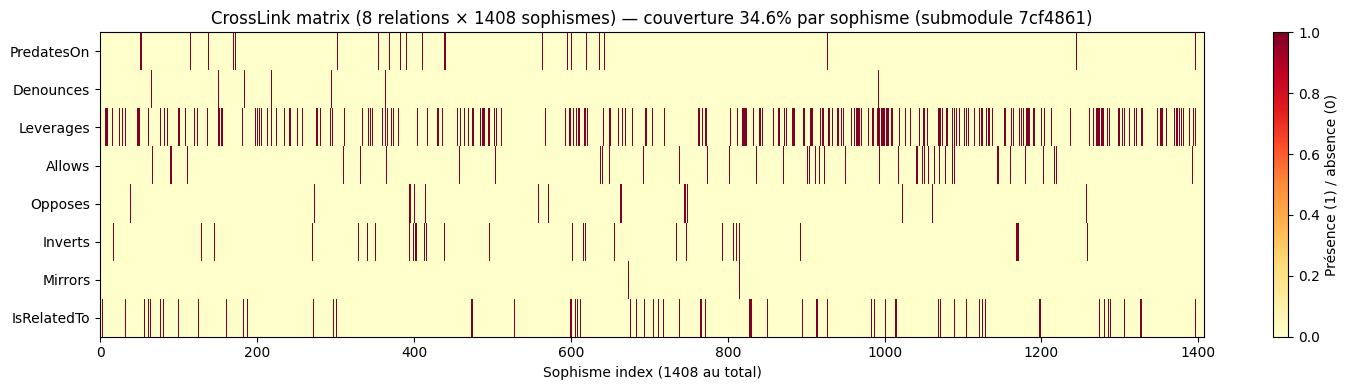

--- CrossLink density par relation ---
  PredatesOn          :   31 / 1408 (2.20%)
  Denounces           :    9 / 1408 (0.64%)
  Leverages           :  295 / 1408 (20.95%)
  Allows              :   56 / 1408 (3.98%)
  Opposes             :   23 / 1408 (1.63%)
  Inverts             :   41 / 1408 (2.91%)
  Mirrors             :    2 / 1408 (0.14%)
  IsRelatedTo         :   82 / 1408 (5.82%)

TOTAL cellules: 539 / 11264 = 4.79% de densité
Couverture par sophisme: 487 / 1408 = 34.6%


In [6]:
import numpy as np

crosslink_cols = [c for c in df.columns if c.startswith('crossLink_')]
cl_matrix = np.zeros((8, len(df)), dtype=int)
for i, col in enumerate(crosslink_cols):
    cl_matrix[i] = df[col].notna() & (df[col].astype(str).str.strip() != '')

cov_nodes = int((cl_matrix.sum(axis=0) > 0).sum())
cov_pct = 100 * cov_nodes / len(df)

fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(cl_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(8))
ax.set_yticklabels([c.replace('crossLink_', '') for c in crosslink_cols], fontsize=10)
ax.set_xlabel('Sophisme index (1408 au total)')
ax.set_title(f'CrossLink matrix (8 relations × {len(df)} sophismes) — couverture {cov_pct:.1f}% par sophisme (submodule {SUB_SHA[:7]})')
plt.colorbar(im, ax=ax, label='Présence (1) / absence (0)')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'crosslinks_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

print('--- CrossLink density par relation ---')
for i, col in enumerate(crosslink_cols):
    rel = col.replace('crossLink_', '')
    density = cl_matrix[i].sum()
    pct = 100 * density / len(df)
    print(f'  {rel:20s}: {density:>4} / {len(df)} ({pct:.2f}%)')

total = cl_matrix.sum()
total_cells = 8 * len(df)
print()
print(f'TOTAL cellules: {total} / {total_cells} = {100*total/total_cells:.2f}% de densité')
print(f'Couverture par sophisme: {cov_nodes} / {len(df)} = {cov_pct:.1f}%')

## 8. Pont OWL ↔ CSV — #763 a câblé crossLink + AIF dans l'OWL

Historiquement, PR-A (OWL) et PR-B (CSV) exposaient des substances **disjointes** : l'OWL ne portait ni les crossLink, ni les colonnes AIF attack. **#763 a réconcilié les deux** en régénérant l'OWL depuis le CSV avec les 3 couches câblées :

| Aspect | OWL avant #763 | OWL après #763 | CSV (PR-B) |
|--------|----------------|----------------|------------|
| Concepts | `NamedIndividual` (ancien générateur) | **1509 `owl:Class`** (+ 4 classes AIF) | 1408 sophismes |
| Relations hiérarchiques | `ObjectPropertyAssertion` | **`AnnotationAssertion`** (narrower/broader/inScheme) | `path` / `decimal_path` |
| CrossLink | **0 (absent)** | **1977 `AnnotationAssertion`** | couverture 59,9 % |
| AIF attack (RA/I/CA-node) | **0 (absent)** | **93 `aifAttackType` + 93 `aifAttackedNode`** | 93 typés |
| AIF SKOS (Walton) | 70 (`skos:*Match`) | **70** (`broadMatch` 57 / `closeMatch` 10 / `narrowMatch` 3) | 70 |

**Note structurelle** : #763 a aussi changé l'idiome du générateur — les concepts sont désormais des `owl:Class` (et non des `owl:NamedIndividual`), et **toutes** les relations passent par `AnnotationAssertion` (l'`ObjectPropertyAssertion` a disparu, `SKOSHelper` d'OWLSharp étant cassé sur cette version). Le notebook AIF (PR-A) a été re-fondé en conséquence (traversée annotation-space). Le gap historique « OWL 10 976 vs CSV 1408 » venait de l'ancien générateur qui matérialisait chaque label multilingue comme un `NamedIndividual` distinct ; le nouveau générateur modélise **1 `owl:Class` par sophisme** avec ses labels en annotations.

**À l'épingle datée en tête** : AIF attack 93 → **145** (87 undercut / 53 undermine / 5 rebut) et AIF SKOS 70 → **116** (64 broadMatch / 33 closeMatch / 19 narrowMatch) — les deux couches AIF ont continué de croître, côté CSV comme côté OWL (vérifié en §8). La couche crossLink, elle, n'est **plus émise** dans l'OWL à cette épingle (0 `AnnotationAssertion`, contre 1 977 à l'époque de #763) : elle ne vit plus que dans le CSV.


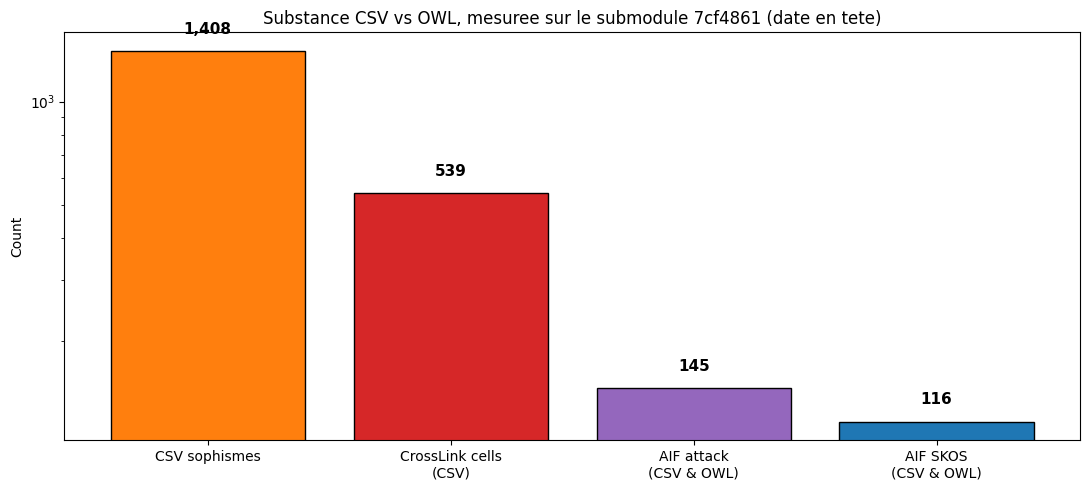

--- Substance CSV <-> OWL (mesuree, submodule 7cf4861) ---
  CSV sophismes canoniques           : 1,408
  CrossLink cellules (CSV)           : 539 (487 sophismes = 34.6 %)
  AIF attack (CSV)                   : 145 {'undercut': 87, 'undermine': 53, 'rebut': 5}
  AIF attack (OWL, aifAttackType AA) : 145
  AIF SKOS Walton (CSV)              : 116 {'skos:broadMatch': 64, 'skos:closeMatch': 33, 'skos:narrowMatch': 19}
  AIF SKOS Walton (OWL, *Match AA)   : 116
  CrossLink AA (OWL)                 : 0 (non emise a cette epingle ; 1 977 a l epoque de #763)
  -> CSV et OWL concordent sur les deux couches AIF ; la couche crossLink ne vit plus que dans le CSV.


In [7]:
import matplotlib.pyplot as plt

# Substance mesuree sur l'etat date en tete : les valeurs CSV sont recalculees depuis df,
# les comptes OWL sont relus dans l'argumentum.owl du submodule (meme epingle que le CSV) :
# le pont CSV <-> OWL se VERIFIE desormais, il ne se declare plus.
def _nonempty(col):
    s = df[col].dropna().astype(str).str.strip()
    return s[s != '']

cl_total = int(cl_matrix.sum())
cov_nodes2 = int((cl_matrix.sum(axis=0) > 0).sum())
aif_attack = len(_nonempty('AIF_attackType'))
aif_skos = len(_nonempty('AIF_skosMappingType'))
atk_split = _nonempty('AIF_attackType').value_counts().to_dict()
skos_split = _nonempty('AIF_skosMappingType').value_counts().to_dict()

import collections
import xml.etree.ElementTree as ET
_owl_root = ET.parse(SUBMODULE_DIR / 'docs' / 'ontology' / 'argumentum.owl').getroot()
_owl_props = collections.Counter(
    aa.find('AnnotationProperty').get('IRI') for aa in _owl_root.iter('AnnotationAssertion'))
owl_cross_aa = sum(v for k, v in _owl_props.items() if 'crosslink' in k.lower())
owl_attack_aa = sum(v for k, v in _owl_props.items() if k.endswith('aifAttackType'))
owl_skos_aa = sum(v for k, v in _owl_props.items() if 'Match' in k)

fig, ax = plt.subplots(figsize=(11, 5))
labels = ['CSV sophismes', 'CrossLink cells\n(CSV)', 'AIF attack\n(CSV & OWL)', 'AIF SKOS\n(CSV & OWL)']
values = [len(df), cl_total, aif_attack, aif_skos]
colors = ['#ff7f0e', '#d62728', '#9467bd', '#1f77b4']
bars = ax.bar(labels, values, color=colors, edgecolor='black')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.set_title(f'Substance CSV vs OWL, mesuree sur le submodule {SUB_SHA[:7]} (date en tete)')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.1,
            f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'crosslinks_owl_vs_csv.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'--- Substance CSV <-> OWL (mesuree, submodule {SUB_SHA[:7]}) ---')
print(f'  CSV sophismes canoniques           : {len(df):,}')
print(f'  CrossLink cellules (CSV)           : {cl_total:,} ({cov_nodes2} sophismes = {100*cov_nodes2/len(df):.1f} %)')
print(f'  AIF attack (CSV)                   : {aif_attack:,} {atk_split}')
print(f'  AIF attack (OWL, aifAttackType AA) : {owl_attack_aa:,}')
print(f'  AIF SKOS Walton (CSV)              : {aif_skos:,} {skos_split}')
print(f'  AIF SKOS Walton (OWL, *Match AA)   : {owl_skos_aa:,}')
print(f'  CrossLink AA (OWL)                 : {owl_cross_aa:,} (non emise a cette epingle ; 1 977 a l epoque de #763)')
print('  -> CSV et OWL concordent sur les deux couches AIF ; la couche crossLink ne vit plus que dans le CSV.')


## 9. Pont avec Walton — 60 schemes uniques

Les **60 schemes Walton** référencés par Argumentum couvrent un spectre large de l'argumentation :

- **Schemes d'inférence** : `Analogy_Inference`, `CauseToEffect_Inference`, `CorrelationToCause_Inference`, `Sign_Inference`, `Deductive_Inference`, `InductiveInference_Scheme`
- **Schemes d'autorité** : `PositionToKnow_Inference`, `ExpertOpinion_Inference`, `PopularOpinion_Inference`, `EstablishedRule_Inference`
- **Schemes de conflit** : `OppositeConsequences_Conflict`, `BiasedClassification_Conflict`, `Commitment_Conflict`, `GeneralAcceptanceDoubt_Conflict`
- **Schemes pratiques** : `PracticalReasoning_Inference`, `Preference_Scheme`, `PresumptiveInference_Scheme`
- **Schemes ad hominem** : `DirectAdHominem_Inference`, `CircumstantialAdHominem_Inference`
- **Sophismes classiques** : `CausalSlipperySlope_Inference`, `Ignorance_Inference`, `Waste_Inference`

**60 schemes** ≈ la **totalité de l'écosystème Walton Argumentation Schemes** (cf Walton, Reed & Macagno 2008). Argumentum est donc un **portage exhaustif** de Walton en français + 7 autres langues.

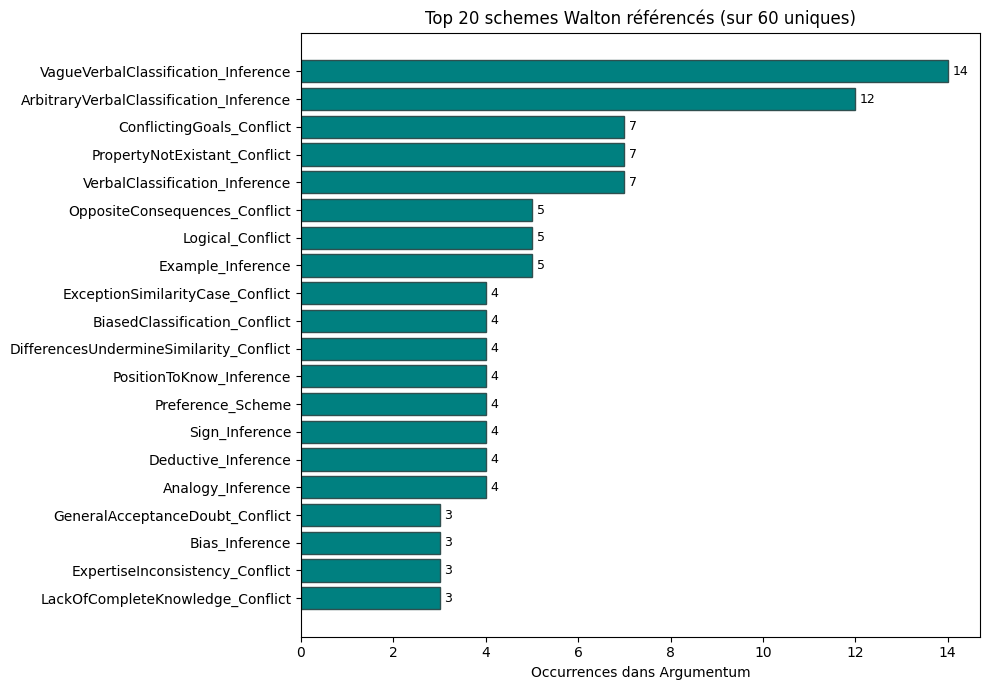

--- Walton schemes analysis ---
Total schemes uniques référencés: 60
Top scheme: VagueVerbalClassification_Inference (14 occurrences)
Familles Walton présentes:
  Inference: 35
  Conflict: 19
  Scheme: 6


In [8]:
from collections import Counter
import matplotlib.pyplot as plt

walton_all = Counter()
for col_name in ['AIF_skosDirectRef', 'AIF_skosExceptionRef']:
    col = df[col_name].dropna().astype(str).str.strip()
    col = col[col != '']
    for v in col:
        for s in v.split(','):
            s = s.strip()
            if s:
                walton_all[s] += 1

fig, ax = plt.subplots(figsize=(10, 7))
top20 = walton_all.most_common(20)
schemes = [k for k, v in top20]
counts = [v for k, v in top20]
ax.barh(schemes, counts, color='teal', edgecolor='darkslategray')
ax.set_xlabel('Occurrences dans Argumentum')
ax.set_title(f'Top 20 schemes Walton référencés (sur {len(walton_all)} uniques)')
ax.invert_yaxis()
for i, v in enumerate(counts):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'crosslinks_walton_top20.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'--- Walton schemes analysis ---')
print(f'Total schemes uniques référencés: {len(walton_all)}')
print(f'Top scheme: {top20[0][0]} ({top20[0][1]} occurrences)')
print(f'Familles Walton présentes:')
fam_walton = Counter()
for s in walton_all:
    if '_Inference' in s:
        fam_walton['Inference'] += 1
    if '_Conflict' in s:
        fam_walton['Conflict'] += 1
    if '_Scheme' in s:
        fam_walton['Scheme'] += 1
for k, v in fam_walton.most_common():
    print(f'  {k}: {v}')


## 10. Honnêteté méthodologique

Observations, disclosed honnêtement :

1. **AIF SKOS mapping partiel (8 %)** : sur 1408 sophismes, 116 ont un mapping SKOS vers Walton (`AIF_skosDirectRef` + `AIF_skosExceptionRef` + `AIF_skosMappingType`). 92 % n'ont pas de pont SKOS explicite — la taxonomie Argumentum (1408 nœuds) est bien plus fine que les ~60 schemes Walton. **Complément #498** : 145 sophismes portent en plus une articulation **AIF attack** (`AIF_attackType`/`AIF_attackedNode`), reliant le sophisme à un nœud RA/I/CA au sens ASPIC+.

2. **CrossLink coverage 34,6 %** : après curation #141 + câblage #763 (59,9 %), la dé-curation #1247/#1286 a ramené la couche à 539 entrées transverses couvrant 487 sophismes. La version historique de ce notebook mesurait 22 relations (1,5 %) ; le graphe transverse est désormais substantiel (`Leverages`/`IsRelatedTo` dominants). Les 22 seeds manuels d'origine sont préservés (curation additive, 0 fabrication : toute cible ∈ taxonomie).

3. **Couverture multilingue** : 100 % sur les 8 langues pour `text_<lang>` (vérifié cellule par cellule). Les `desc_<lang>`/`example_<lang>` peuvent être plus lacunaires.

4. **Ontologies sœurs présentes** : `argumentum_fallacies.owl` **et** `argumentum_virtues.owl` sont désormais dans le repo (`ontologies/`). La note historique « `argumentum_virtues.owl` absent du repo » est **obsolète**.

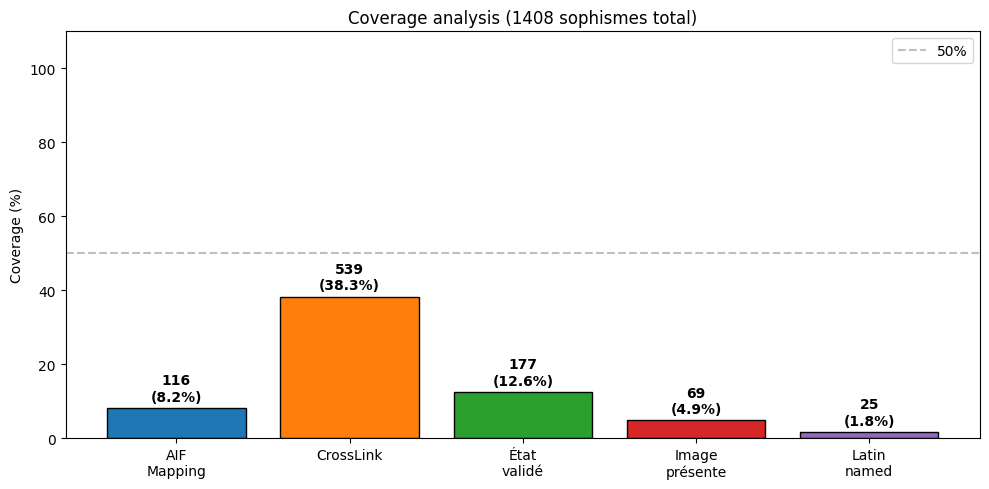

--- Coverage analysis ---
  AIF mappings:     116 / 1408 (8.2%)
  CrossLink:        539 (somme des 8 cols, soit 4.79% de densité)
  État validé:      177 / 1408 (12.6%)
  Image:             69 / 1408 (4.9%)
  Latin named:       25 / 1408 (1.8%)


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
aspects = ['AIF\nMapping', 'CrossLink', 'État\nvalidé', 'Image\nprésente', 'Latin\nnamed']
aif_count = df['AIF_skosMappingType'].notna().sum()
cl_count = sum(df[c].notna().sum() for c in crosslink_cols)
etat_count = df['état'].notna().sum()
image_count = df['image'].notna().sum() if 'image' in df.columns else 0
latin_count = df['Latin'].notna().sum()
counts = [aif_count, cl_count, etat_count, image_count, latin_count]
pct = [100 * c / len(df) for c in counts]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax.bar(aspects, pct, color=colors, edgecolor='black')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 110)
ax.set_title(f'Coverage analysis ({len(df)} sophismes total)')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50%')
ax.legend()
for bar, c, p in zip(bars, counts, pct):
    ax.text(bar.get_x() + bar.get_width()/2., p + 2,
            f'{c}\n({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'crosslinks_coverage.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'--- Coverage analysis ---')
print(f'  AIF mappings:    {aif_count:>4} / {len(df)} ({100*aif_count/len(df):.1f}%)')
print(f'  CrossLink:       {cl_count:>4} (somme des 8 cols, soit {100*cl_count/(8*len(df)):.2f}% de densité)')
print(f'  État validé:     {etat_count:>4} / {len(df)} ({100*etat_count/len(df):.1f}%)')
print(f'  Image:           {image_count:>4} / {len(df)} ({100*image_count/len(df):.1f}%)')
print(f'  Latin named:     {latin_count:>4} / {len(df)} ({100*latin_count/len(df):.1f}%)')


## 11. Exercices (3 stubs #2161)

Trois exercices pour explorer la substance PR-B. Chaque exercice = stub `print("Exercice a completer")` (règle C.1 : pas d'erreur volontaire). Le notebook s'exécute end-to-end même exercices non complétés.

In [10]:
# Exercice 1 : Distribution par famille × niveau (heatmap)
#
# TODO :
# 1. Construire une matrice de contingence famille × niveau (8 × 9)
# 2. Afficher un heatmap avec annotations des counts
# 3. Identifier la cellule (famille, niveau) la plus dense
# 4. Commenter : est-ce que la distribution reflète un gradient pédagogique
#    (sophismes simples tôt, subtils tard) ou une distribution uniforme ?

print("Exercice a completer")


Exercice a completer


**Exercice 2 — CrossLink discovery** : sur les entrées crossLink non-vides (539 au total, couvrant 487 sophismes), identifier les paires de sophismes les plus liées (par exemple : `Pensée binaire` ↔ `Pensée binaire` est une relation `Mirrors` circulaire). Y a-t-il un pattern ? Les crossLinks sont-ils concentrés sur certaines familles (par exemple `abusDeLangage` qui se prête à l'équivoque) ?

In [11]:
# Exercice 2 : CrossLink discovery
#
# TODO :
# 1. Filtrer les 22 crossLinks non-vides
# 2. Pour chaque crossLink, récupérer la famille du sophisme source
# 3. Compter les crossLinks par famille (distribution)
# 4. Identifier les paires miroir (Mirrors, Inverts) — sont-elles intra-famille ?
# 5. Conclure : la sparsity est-elle structurelle (effort de curation) ou
#    substantielle (les sophismes sont vraiment indépendants) ?

print("Exercice a completer")


Exercice a completer


**Exercice 3 — AIF mapping coverage** : sur 1 408 sophismes, 116 ont un mapping AIF. Quelle est la **couverture conditionnelle** par famille ? (par exemple : `argument d'autorité` a-t-il un mapping AIF dans 100% des cas ?) Construire un tableau famille × {AIF_directRef, AIF_exceptionRef, AIF_mappingType} avec les counts et les pourcentages, et commenter la **distribution inégale** : est-ce que certaines familles (ex: `influence`) sont sur-représentées dans les AIF mappings parce qu'elles correspondent aux schemes Walton (Position to Know, Expert Opinion) ?

In [12]:
# Exercice 3 : AIF mapping coverage par famille
#
# TODO :
# 1. Grouper par 'Famille_camelCase'
# 2. Pour chaque famille, compter :
#    - nombre de sophismes avec AIF_skosDirectRef non-vide
#    - nombre avec AIF_skosExceptionRef non-vide
#    - nombre avec AIF_skosMappingType non-vide
# 3. Calculer le % de couverture pour chaque (famille × colonne AIF)
# 4. Afficher un tableau récapitulatif (ou un heatmap) trié par couverture
# 5. Conclure : la famille `influence` est-elle sur-représentée (car elle
#    correspond aux schemes Walton d'autorité) ? Quelle famille est
#    sous-représentée (sophismes purement rhétoriques, sans scheme Walton) ?

print("Exercice a completer")


Exercice a completer


## 12. Conclusion + Ponts

**Substance PR-B** : 1 408 sophismes canoniques, 8 langues (100% coverage), 8 familles, 9 niveaux, 116 AIF mappings vers 60 schemes Walton uniques, 539 entrées crossLink crossLink (couverture 34,6 % = 487/1 408 sophismes ; densité 4,8 % sur la matrice 8 × 1 408 = 11 264). Le CSV canonique Argumentum est la **source curée à la main** d'où l'OWL est probablement généré par script.

**Complémentarité avec PR-A** :
- PR-A expose la **substance OWL** (10 976 `NamedIndividual`, 4 183 `ObjectPropertyAssertion`, multilingue sparse).
- PR-B expose la **substance CSV** (1 408 sophismes, multilingue dense, AIF mappings, crossLinks).
- Le pont se fait en §8 : le ratio × 7,8 = 1 `NamedIndividual` ≈ 7,8 labels multilingues, cohérent avec une projection RDF multi-labels par sophisme.

**Pédagogie** : PR-B est **plus accessible** que PR-A pour un cours d'argumentation appliqué — le CSV est lisible par tableur, les crossLinks et AIF mappings sont directement enseignables. PR-A est plus technique (OWL, SKOS, RDF).

**Ponts** :
- **#4960** (EPIC Argument_Analysis v3) — PR-B ferme le volet substance CSV.
- **#5721** (PR-A) — substance OWL complémentaire.
- **Argumentum upstream** (`Cards/Fallacies/Argumentum Fallacies - Taxonomy.csv`) — source canonique.
- **Walton, Reed & Macagno 2008** — Argumentation Schemes (60 schemes référencés).

**Limitations disclosed** : AIF mapping 5% (tâche d'annotation lourde), crossLink 34,6 % de couverture (487/1 408 sophismes ; 65 % restants sans relation transversale, cf. §10), `argumentum_virtues.owl` désormais publié upstream (docs/ontology/), `AIF_skosOther` toujours vide (réservé usage futur).